#### Fig 2a.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

Copying code from https://zenodo.org/records/10012934 to create a NMF dotplot with custom ordered faftsors

In [6]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/h5ad/adata_vis_assigned_cell_types_nfact12.h5ad")


In [4]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266,0.010062,0.009213,0.056085,0.024774,0.080588,0.040189,0.030853,0.005049,0.038562,0.017642,0.068411,0.598156,0.124178,0.036192,0.026985,0.061592,0.055564,0.479931,0.034395,0.011473,0.129968,0.007446,0.244876,0.049037,0.007688,0.022190,0.089888,0.012039,0.379554,EC aerocyte capillary,9.937147,0.000000,1.645782,0.000000,0.261246,3.300004,0.000000,0.000000,0.000000,0.410853,0.000000,0.000000
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1

In [5]:
adata_vis

AnnData object with n_obs × n_vars = 160702 × 16959
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'alignment', 'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx', 'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date', 'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex', 'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long', 'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'training_batch', 'AT0', 'AT1', 'AT2', 'AT2 proliferating', 'Adventitial fibroblasts', 'Alveolar Mph CCL3+', 'Alveolar Mph M

In [6]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266,0.010062,0.009213,0.056085,0.024774,0.080588,0.040189,0.030853,0.005049,0.038562,0.017642,0.068411,0.598156,0.124178,0.036192,0.026985,0.061592,0.055564,0.479931,0.034395,0.011473,0.129968,0.007446,0.244876,0.049037,0.007688,0.022190,0.089888,0.012039,0.379554,EC aerocyte capillary,9.937147,0.000000,1.645782,0.000000,0.261246,3.300004,0.000000,0.000000,0.000000,0.410853,0.000000,0.000000
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1

In [9]:
import pickle
def unpickle_model(path, mod_name):
    r"""Unpickle model
    """
    file = path + 'model_' + mod_name + ".p" 
    mod1_ann = pickle.load(file = open(file, "rb"))
    return mod1_ann['mod']

In [10]:
n_fact = 12
mod_path = "/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/cell2location/CoLocatedComb_r12/CoLocatedGroupsSklearnNMF_160702locations_56factors/models/"

In [11]:
mod_sk = unpickle_model(mod_path, f'n_fact{n_fact}')

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.5.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [12]:
mod_sk.cell_type_fractions

,fact_0,fact_1,fact_2,fact_3,fact_4,fact_5,fact_6,fact_7,fact_8,fact_9,fact_10,fact_11
AT0,0.348049,0.000000,0.441051,0.000000,0.000000,0.003235,0.000000,0.000000,0.014634,0.000000,0.181598,0.011433
AT1,0.885284,0.009559,0.028775,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076381,0.000000
AT2,0.278700,0.000000,0.000000,0.000000,0.004184,0.016708,0.000000,0.000000,0.000000,0.000000,0.700408,0.000000
AT2 proliferating,0.479942,0.000000,0.042979,0.000000,0.000000,0.093128,0.000000,0.000000,0.010206,0.000000,0.360935,0.012810
Adventitial fibroblasts,0.005006,0.000000,0.000000,0.000000,0.000000,0.182678,0.737432,0.000000,0.000114,0.064486,0.000000,0.010284
Alveolar Mph CCL3+,0.279124,0.000000,0.000000,0.000000,0.312208,0.000000,0.000000,0.214707,0.084212,0.000000,0.109748,0.000000
Alveolar Mph MT-positive,0.463141,0.000000,0.000000,0.000000,0.102193,0.191323,0.000000,0.035901,0.160649,0.000000,0.046793,0.000000
Alveolar Mph proliferating,0.499390,0.000000,0.000000,0.000000,0.347518,0.123449,0.000000,0.000000,0.000000,0.000000,0.029643,0.000000
Alveolar fibroblasts,0.223718,0.000000,0.000000,0.000000,0.000000,0.766426,0.000000,0.000000,0.000000,0.000000,0.009856,0.000000
Alveolar macrophages,0.179850,0.000000,0.000000,0.000000,0.791019,0.007663,0.000000,0.000000,0.000000,0.000000,0.021468,0.000000


In [13]:
cts_nmf = mod_sk.cell_type_fractions.index.values.copy()

In [14]:
cts_nmf

array(['AT0', 'AT1', 'AT2', 'AT2 proliferating',
       'Adventitial fibroblasts', 'Alveolar Mph CCL3+',
       'Alveolar Mph MT-positive', 'Alveolar Mph proliferating',
       'Alveolar fibroblasts', 'Alveolar macrophages', 'B cells',
       'Basal resting', 'CD4 T cells', 'CD8 T cells',
       'Classical monocytes', 'Club (nasal)', 'Club (non-nasal)', 'DC1',
       'DC2', 'Deuterosomal', 'EC aerocyte capillary', 'EC arterial',
       'EC general capillary', 'EC venous pulmonary',
       'EC venous systemic', 'Goblet (bronchial)', 'Goblet (nasal)',
       'Goblet (subsegmental)', 'Hillock-like',
       'Interstitial Mph perivascular', 'Ionocyte',
       'Lymphatic EC differentiating', 'Lymphatic EC mature',
       'Mast cells', 'Mesothelium', 'Migratory DCs',
       'Monocyte-derived Mph', 'Multiciliated (nasal)',
       'Multiciliated (non-nasal)', 'Myofibroblasts', 'NK cells',
       'Neuroendocrine', 'Non-classical monocytes',
       'Peribronchial fibroblasts', 'Pericytes', 'Plasm

In [15]:
filter_cts_list = ['AT2 proliferating','Alveolar Mph MT-positive','Alveolar Mph proliferating',
                   'Basal resting','Classical monocytes','Club (nasal)', 'Club (non-nasal)', 'DC1',
       'DC2', 'Deuterosomal','Goblet (bronchial)', 'Goblet (nasal)',
       'Goblet (subsegmental)', 'Hillock-like','Ionocyte','Mesothelium', 'Migratory DCs',
        'Multiciliated (nasal)','Neuroendocrine', 'Non-classical monocytes','Plasmacytoid DCs', 'SM activated stress response', 'SMG duct', 'Unknown', 'Suprabasal']

In [16]:
cts_nmf_filtered = [ct for ct in cts_nmf if ct not in filter_cts_list]

In [17]:
import matplotlib
from cell2location.plt.plot_heatmap import clustermap
fact_ordered = reversed(['fact_6','fact_3','fact_0',    'fact_9',
                'fact_5','fact_10','fact_4','fact_7','fact_1','fact_11',
                'fact_8','fact_2'])

In [18]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)


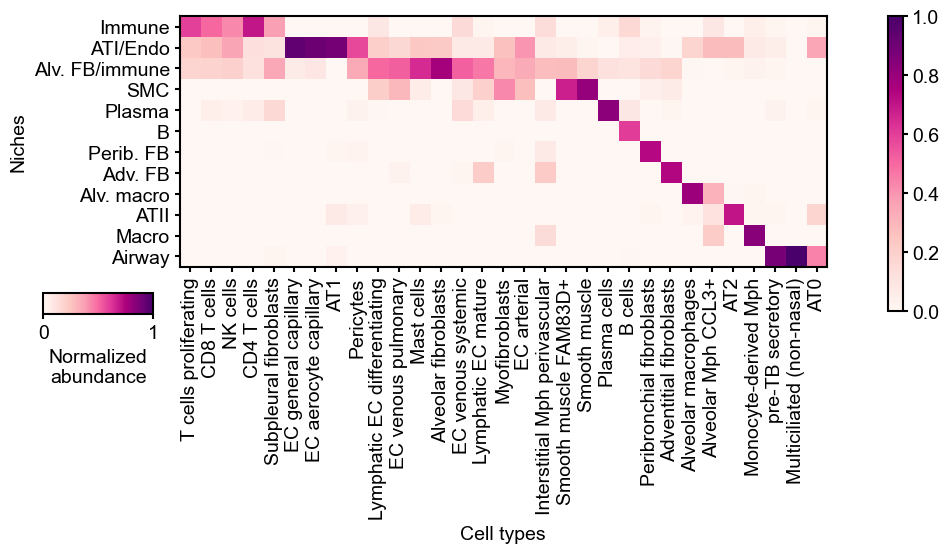

In [19]:
import matplotlib
from cell2location.plt.plot_heatmap import clustermap
fact_ordered = ['fact_8','fact_0','fact_5',    'fact_9',
                'fact_11','fact_3','fact_1','fact_6','fact_4','fact_10',
                'fact_7','fact_2']
clustermap(mod_sk.cell_type_fractions.loc[cts_nmf_filtered ,fact_ordered].T,
           cluster_rows=False, cluster_cols=True,
           figure_size=[8,5])

plt.colorbar(orientation="horizontal", shrink = 0.2, aspect = 5, location = 'bottom', pad =0, anchor = (-0.6, -0.15), 
             label = "Normalized\nabundance")


plt.yticks(ticks = [0,1,2,3,4,5,6,7,8,9,10,11], 
          labels = [
              "Immune", "ATI/Endo", "Alv. FB/immune", "SMC", "Plasma", "B", "Perib. FB", "Adv. FB", "Alv. macro", "ATII", "Macro", "Airway"

          ])
plt.ylabel("Niches")
plt.xticks(rotation = 90)
plt.xlabel("Cell types")
plt.yticks(rotation = 0)
plt.savefig(os.path.join(save_dir,"nfact_12_reordered.pdf"), bbox_inches='tight', transparent = True)
plt.show()

In [20]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266,0.010062,0.009213,0.056085,0.024774,0.080588,0.040189,0.030853,0.005049,0.038562,0.017642,0.068411,0.598156,0.124178,0.036192,0.026985,0.061592,0.055564,0.479931,0.034395,0.011473,0.129968,0.007446,0.244876,0.049037,0.007688,0.022190,0.089888,0.012039,0.379554,EC aerocyte capillary,9.937147,0.000000,1.645782,0.000000,0.261246,3.300004,0.000000,0.000000,0.000000,0.410853,0.000000,0.000000
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1

Assign spots to factors based on max value

In [21]:
adata_vis.obs.shape

(160702, 126)

In [22]:
fts = ['mean_nUMI_factorsfact_0',
         'mean_nUMI_factorsfact_1',
         'mean_nUMI_factorsfact_2',
         'mean_nUMI_factorsfact_3',
         'mean_nUMI_factorsfact_4',
         'mean_nUMI_factorsfact_5',
         'mean_nUMI_factorsfact_6',
         'mean_nUMI_factorsfact_7',
         'mean_nUMI_factorsfact_8',
         'mean_nUMI_factorsfact_9',
         'mean_nUMI_factorsfact_10',
         'mean_nUMI_factorsfact_11']

In [23]:
# Create a new column to store the assigned cell type
assigned_factors = []

# Iterate over each spot (row) in adata_vis.obs
for index, row in adata_vis.obs.iterrows():
    # Get the probabilities for each cell type in list ct
    probabilities = row[fts].values
    
    # Get the index of the column with the maximum probability
    max_prob_idx = np.argmax(probabilities)
    
    # Get the name of the cell type corresponding to this index (assuming column names are like 'factor_X')
    assigned_factor = fts[max_prob_idx]
    
    assigned_factors.append(assigned_factor)  # Add the assigned cell type


In [24]:
# Add the assigned cell types to `adata_vis.obs`
adata_vis.obs['factor_assigned'] = assigned_factors
adata_vis.obs['factor_assigned'] = adata_vis.obs['factor_assigned'].astype('category')

In [25]:
adata_vis.obs["ATI/Endo"] = adata_vis.obs["mean_nUMI_factorsfact_0"]
adata_vis.obs["Perib. FB"] = adata_vis.obs["mean_nUMI_factorsfact_1"]
adata_vis.obs["Airway"] = adata_vis.obs["mean_nUMI_factorsfact_2"]
adata_vis.obs["B"] = adata_vis.obs["mean_nUMI_factorsfact_3"]
adata_vis.obs["Alv. macro"] = adata_vis.obs["mean_nUMI_factorsfact_4"]
adata_vis.obs["Alv. FB/immune"] = adata_vis.obs["mean_nUMI_factorsfact_5"]
adata_vis.obs["Adv. FB"] = adata_vis.obs["mean_nUMI_factorsfact_6"]
adata_vis.obs["Macro"] = adata_vis.obs["mean_nUMI_factorsfact_7"]
adata_vis.obs["Immune"] = adata_vis.obs["mean_nUMI_factorsfact_8"]
adata_vis.obs["SMC"] = adata_vis.obs["mean_nUMI_factorsfact_9"]
adata_vis.obs["ATII"] = adata_vis.obs["mean_nUMI_factorsfact_10"]
adata_vis.obs["Plasma"] = adata_vis.obs["mean_nUMI_factorsfact_11"]

In [26]:
adata_vis.obs["factor_assigned"] = adata_vis.obs["factor_assigned"].cat.rename_categories({
    'mean_nUMI_factorsfact_0': 'ATI/Endo',
    'mean_nUMI_factorsfact_1': 'Perib. FB',
    'mean_nUMI_factorsfact_2': 'Airway',
    'mean_nUMI_factorsfact_3': 'B',
    'mean_nUMI_factorsfact_4': 'Alv. macro',
    'mean_nUMI_factorsfact_5': 'Alv. FB/immune',
    'mean_nUMI_factorsfact_6': 'Adv. FB',
    'mean_nUMI_factorsfact_7': 'Macro',
    'mean_nUMI_factorsfact_8': 'Immune',
    'mean_nUMI_factorsfact_9': 'SMC',
    'mean_nUMI_factorsfact_10': 'ATII',
    'mean_nUMI_factorsfact_11': 'Plasma',

})

In [27]:
h5ad_savedir = "h5ad"
os.makedirs(h5ad_savedir, exist_ok=True)

In [28]:
adata_vis.write(os.path.join(h5ad_savedir,"adata_vis_assigned_cell_types_nfact12.h5ad"))

In [29]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,factor_assigned,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,B,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266,0.010062,0.009213,0.056085,0.024774,0.080588,0.040189,0.030853,0.005049,0.038562,0.017642,0.068411,0.598156,0.124178,0.036192,0.026985,0.061592,0.055564,0.479931,0.034395,0.011473,0.129968,0.007446,0.244876,0.049037,0.007688,0.022190,0.089888,0.012039,0.379554,EC aerocyte capillary,9.937147,0.000000,1.645782,0.000000,0.261246,3.